In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBClassifier
import joblib


print('Libraries loaded successfully!')

Libraries loaded successfully!


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Datasets/creditcard.csv')
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
print(df['Class'].value_counts())

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

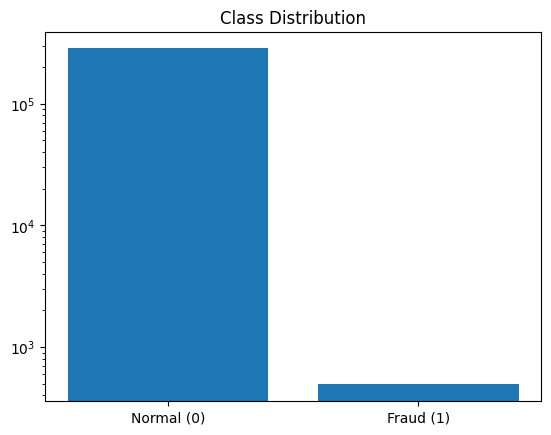

In [7]:
counts = df['Class'].value_counts()
plt.bar(['Normal (0)', 'Fraud (1)'], counts)
plt.yscale('log')
plt.title('Class Distribution')
plt.show()

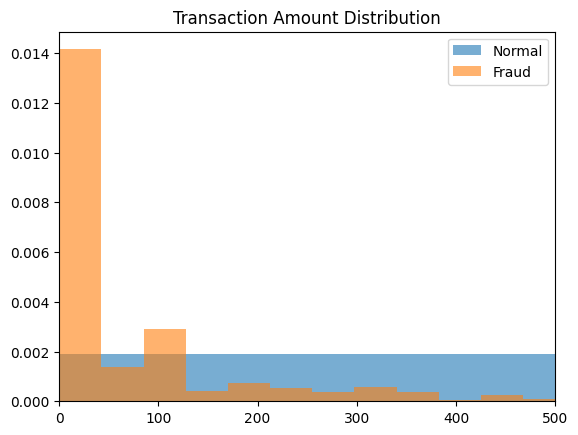

In [8]:
normal_amt = df[df['Class'] == 0]['Amount']
fraud_amt = df[df['Class'] == 1]['Amount']

plt.hist(normal_amt, bins=50, alpha=0.6, label='Normal', density=True)
plt.hist(fraud_amt, bins=50, alpha=0.6, label='Fraud', density=True)
plt.xlim(0, 500)
plt.legend()
plt.title('Transaction Amount Distribution')
plt.show()

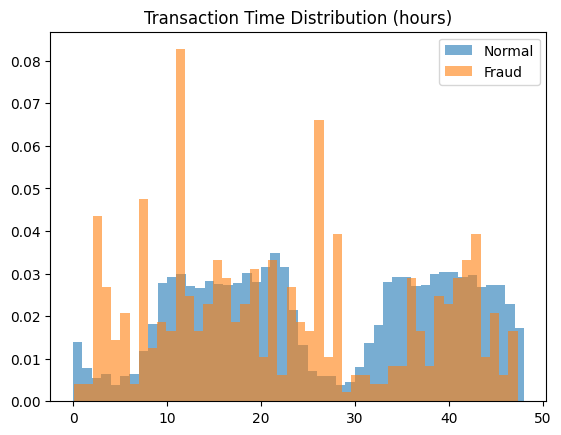

In [10]:
normal_time = df[df['Class'] == 0]['Time'] / 3600   # convert seconds to hours
fraud_time = df[df['Class'] == 1]['Time'] / 3600

plt.hist(normal_time, bins=48, alpha=0.6, label='Normal', density=True)
plt.hist(fraud_time, bins=48, alpha=0.6, label='Fraud', density=True)
plt.legend()
plt.title('Transaction Time Distribution (hours)')
plt.show()

In [11]:
print("Normal transactions - Amount stats:")
print(normal_amt.describe())

print("\nFraud transactions - Amount stats:")
print(fraud_amt.describe())

Normal transactions - Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud transactions - Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [13]:
X = df.drop(columns=['Class'])
y = df['Class']

In [14]:
scaler = StandardScaler()
X['Time'] = scaler.fit_transform(X[['Time']])
X['Amount'] = scaler.fit_transform(X[['Amount']])

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [19]:
preds = model.predict(X_test)
probs = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds, digits=3))
print(confusion_matrix(y_test, preds))
print('ROC-AUC:', roc_auc_score(y_test, probs))


              precision    recall  f1-score   support

           0      1.000     0.976     0.988     56864
           1      0.061     0.918     0.114        98

    accuracy                          0.975     56962
   macro avg      0.530     0.947     0.551     56962
weighted avg      0.998     0.975     0.986     56962

[[55475  1389]
 [    8    90]]
ROC-AUC: 0.9721669425367221


In [20]:
# Tell XGBoost how imbalanced the classes are, so it weighs fraud examples appropriately
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

In [21]:
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, xgb_preds, digits=3))
print(confusion_matrix(y_test, xgb_preds))
print('ROC-AUC:', roc_auc_score(y_test, xgb_probs))

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.844     0.827     0.835        98

    accuracy                          0.999     56962
   macro avg      0.922     0.913     0.917     56962
weighted avg      0.999     0.999     0.999     56962

[[56849    15]
 [   17    81]]
ROC-AUC: 0.9772181100915325


In [22]:
joblib.dump(xgb_model, 'xgb_fraud_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']